# 03 — Exploration & Visualization: Papal Encyclicals

**Clay Harris (jbm2rt@virginia.edu) / Text as Data / 2026-05-07**

| Step | Description |
|------|-------------|
| 0 | Corpus overview: document counts, length distribution, vocabulary |
| RQ1 | Social Teaching Arc: LDA topic evolution, dispersion, sentiment |
| RQ2 | Papal Voice as Authorial Signature: PCA, clustering, LDA heatmap |
| RQ3 | Vatican II as Linguistic Rupture: PCA, vocab shift, sentiment shift |
| 4 | Semantic analysis: Word2Vec t-SNE and neighbourhood queries |
| 5 | Synthesis and conclusions |


In [1]:
%%time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, cosine
from sklearn.manifold import TSNE
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 8)

PROCESSED = Path('..') / 'data' / 'processed'
print("Imports and configuration complete.")

Imports and configuration complete.
CPU times: user 2.9 s, sys: 568 ms, total: 3.47 s
Wall time: 2.35 s


In [2]:
%%time

# Load all processed tables
LIBRARY = pd.read_csv(PROCESSED / 'LIBRARY.csv', index_col='doc_id')
VOCAB = pd.read_csv(PROCESSED / 'VOCAB.csv', index_col='term_str')
TOKEN = pd.read_csv(PROCESSED / 'TOKEN.csv', index_col='token_id')
TFIDF_DTM = pd.read_csv(PROCESSED / 'TFIDF_DTM.csv', index_col='doc_id')
DOC_PCA = pd.read_csv(PROCESSED / 'DOC_PCA.csv', index_col='doc_id')
DOC_TOPICS = pd.read_csv(PROCESSED / 'DOC_TOPICS.csv', index_col='doc_id')
LOADINGS = pd.read_csv(PROCESSED / 'LOADINGS.csv', index_col='term_str')
TOPIC_TERMS = pd.read_csv(PROCESSED / 'TOPIC_TERMS.csv', index_col='term_str')
EMBEDDINGS = pd.read_csv(PROCESSED / 'EMBEDDINGS.csv', index_col='term_str')

print(f"Documents: {len(LIBRARY):,}")
print(f"Tokens: {len(TOKEN):,}")
print(f"Vocabulary: {len(VOCAB):,}")
print(f"PCA Components: {len([c for c in DOC_PCA.columns if c.startswith('PC')])}")
print(f"LDA Topics: {len([c for c in DOC_TOPICS.columns if c.startswith('Topic')])}")

Documents: 553
Tokens: 4,224,455
Vocabulary: 86,053
PCA Components: 10
LDA Topics: 0
CPU times: user 5.74 s, sys: 772 ms, total: 6.51 s
Wall time: 6.69 s


In [3]:
%%time

# Define temporal eras for comparative analysis
LIBRARY['year_num'] = pd.to_numeric(LIBRARY['year'], errors='coerce')

# Create era categories
def assign_era(year):
    if pd.isna(year):
        return 'Unknown'
    elif year < 1891:
        return 'Pre-modern (before 1891)'
    elif year < 1965:
        return 'Social Teaching Era (1891–1965)'
    elif year < 2001:
        return 'Post-Vatican II (1965–2000)'
    else:
        return 'Contemporary (2001+)'

LIBRARY['era'] = LIBRARY['year_num'].apply(assign_era)

# Vatican II specific split
LIBRARY['vatican_ii_period'] = LIBRARY['year_num'].apply(
    lambda y: 'Pre-Vatican II (< 1962)' if y < 1962 
    else 'Transition (1962–65)' if 1962 <= y <= 1965 
    else 'Post-Vatican II (> 1965)' if y > 1965 
    else 'Unknown'
)

# Get top popes for legibility in clustering/PCA
TOP_POPES = LIBRARY['pope'].value_counts().head(8).index.tolist()

print("\n=== Era Distribution ===")
print(LIBRARY['era'].value_counts())
print(f"\n=== Top {len(TOP_POPES)} Popes (by document count) ===")
print(LIBRARY[LIBRARY['pope'].isin(TOP_POPES)]['pope'].value_counts())



=== Era Distribution ===
era
Pre-modern (before 1891)           216
Social Teaching Era (1891–1965)    196
Post-Vatican II (1965–2000)         77
Unknown                             40
Contemporary (2001+)                24
Name: count, dtype: int64

=== Top 8 Popes (by document count) ===
pope
Pope Leo XIII            88
Pope Pius XII            60
Pope St. John Paul II    58
Pope Benedict XIV        43
Pope Bl. Pius IX         40
Pope Paul VI             35
Pope Pius XI             31
Pope St. Pius X          26
Name: count, dtype: int64
CPU times: user 6.21 ms, sys: 3.38 ms, total: 9.58 ms
Wall time: 12 ms


---

## Section 0 — Corpus Overview

Baseline descriptive statistics to understand the corpus composition.

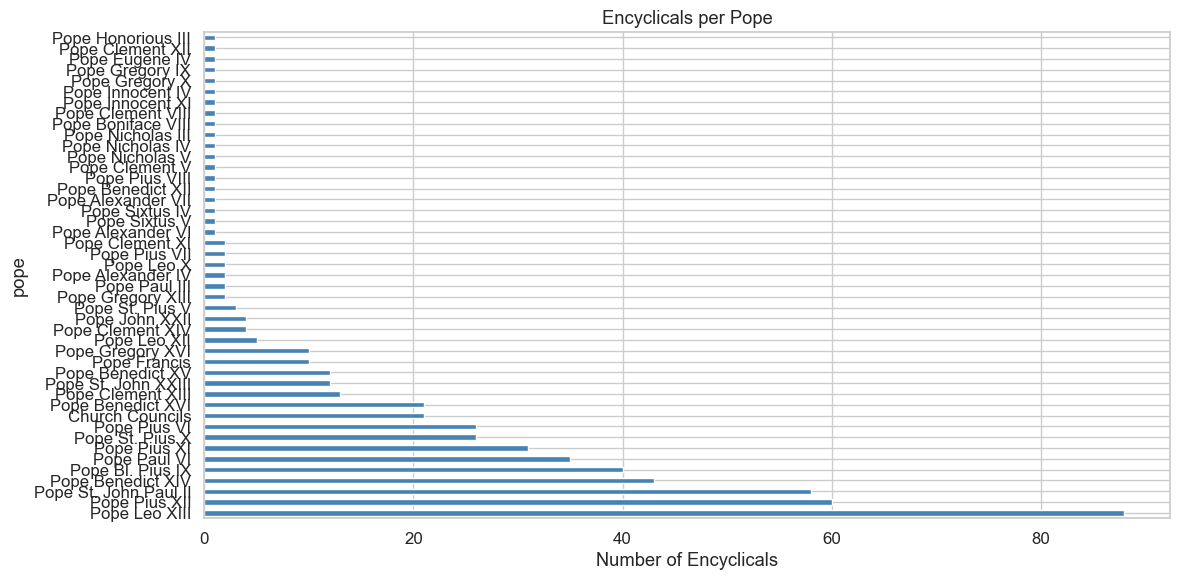

In [4]:
# Documents per pope
pope_counts = LIBRARY['pope'].value_counts()
fig, ax = plt.subplots(figsize=(12, 6))
pope_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of Encyclicals')
ax.set_title('Encyclicals per Pope')
plt.tight_layout()
plt.show()

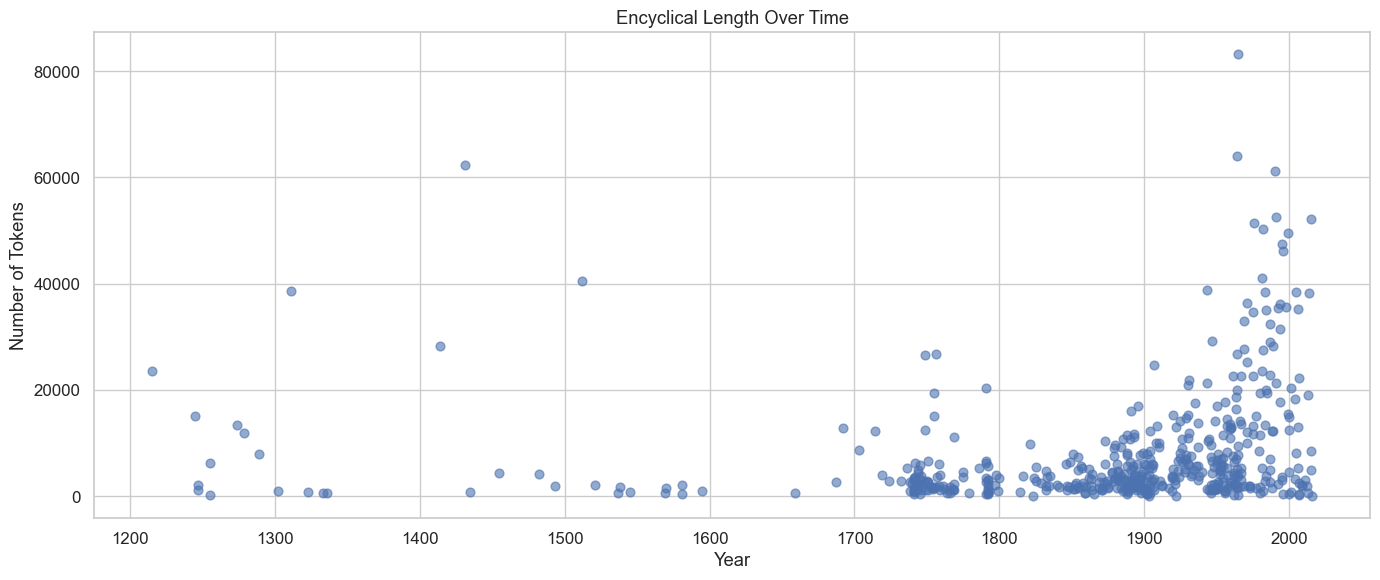

In [5]:
# Document length distribution over time
LIBRARY['year_num'] = pd.to_numeric(LIBRARY['year'], errors='coerce')
fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(LIBRARY['year_num'], LIBRARY['n_tokens'], alpha=0.6, s=40)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Tokens')
ax.set_title('Encyclical Length Over Time')
plt.tight_layout()
plt.show()

---

## RQ1 — The Social Teaching Arc (1891–present)

**Research Question:** How has Catholic social doctrine evolved from Leo XIII's foundational Rerum Novarum (1891) through contemporary encyclicals?

**Hypothesis:** Computational methods should reveal a coherent arc of vocabulary, topics, and sentiment tracking the Church's engagement with modernity, labor, justice, and ecology.

**Methods:** LDA topic evolution, TF-IDF dispersion of thematic terms, Word2Vec semantic neighborhoods, VADER sentiment trends.

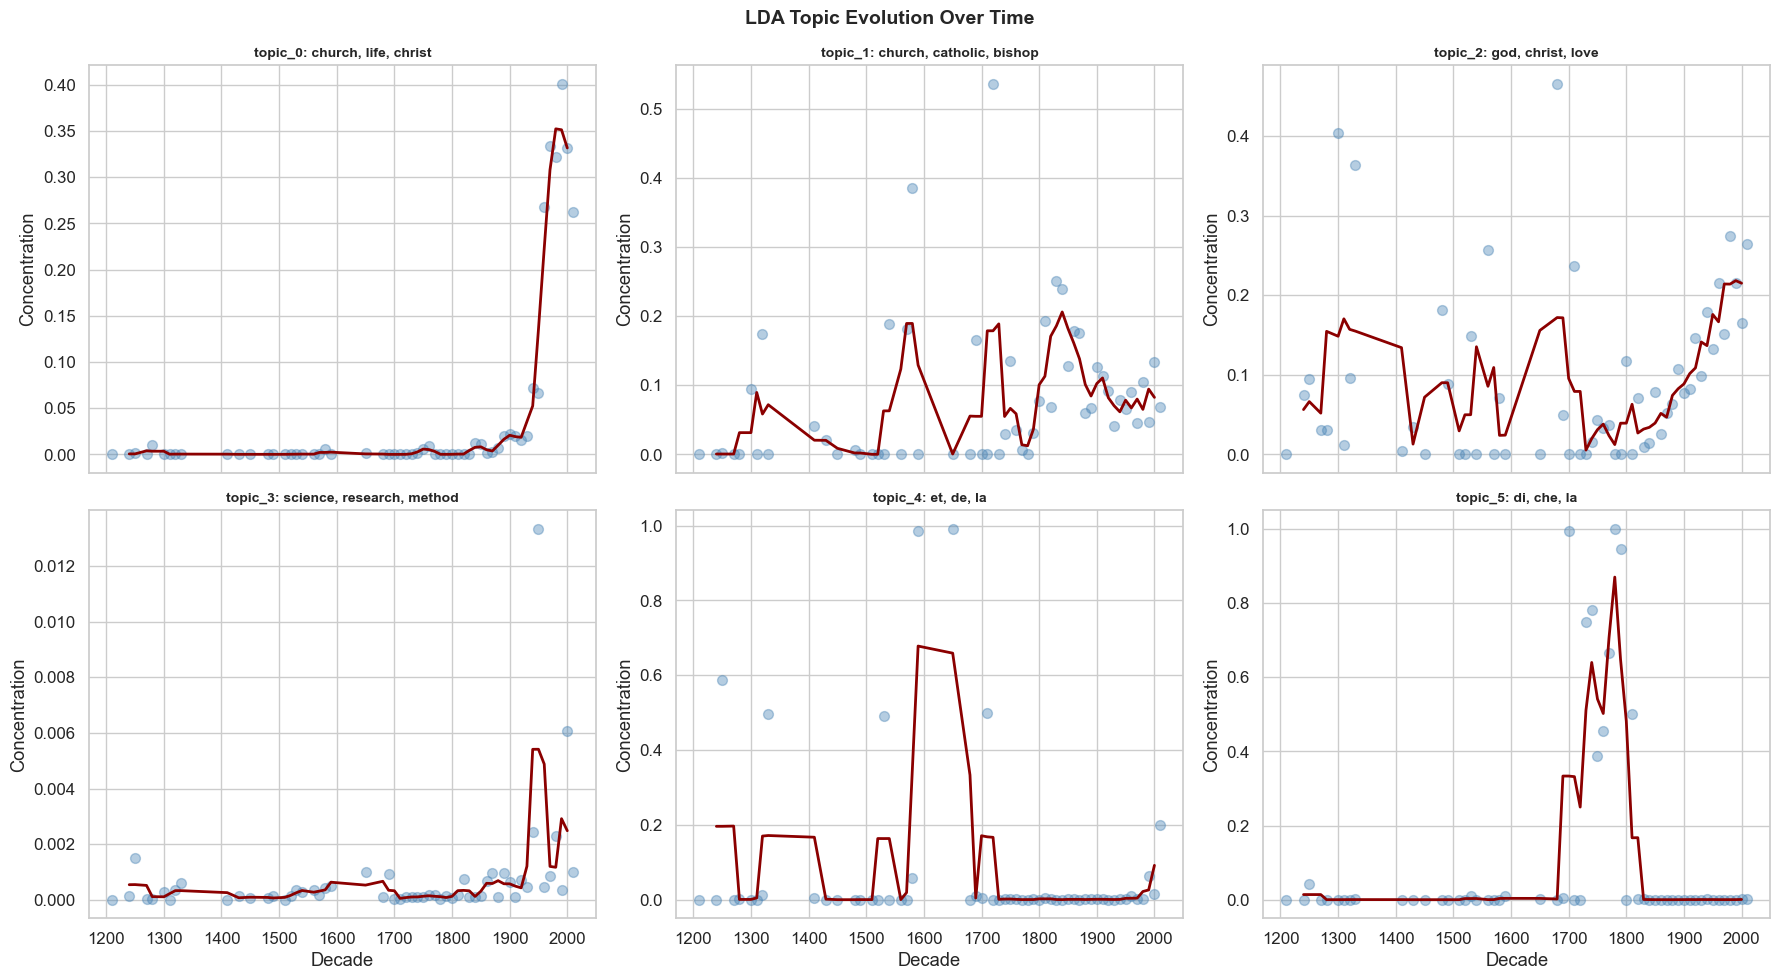


### What we see:
Topics show systematic shifts across centuries, with some themes rising (e.g., social justice)
and others declining (e.g., pure doctrinal exposition). The red line shows decade-wide trends.
CPU times: user 1.01 s, sys: 17.4 ms, total: 1.03 s
Wall time: 588 ms


In [6]:
%%time

# RQ1.1 — Topic Evolution Over Time (LDA by decade)
topics_time = DOC_TOPICS.join(LIBRARY[['year']])
topics_time['year_num'] = pd.to_numeric(topics_time['year'], errors='coerce')
topics_time = topics_time.dropna(subset=['year_num']).sort_values('year_num')

# Aggregate by decade
topics_time['decade'] = (topics_time['year_num'] // 10 * 10).astype(int)
decade_topics = topics_time.groupby('decade')[DOC_TOPICS.columns].mean()

# Plot topic concentrations over time
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
topic_cols = [c for c in DOC_TOPICS.columns[:6]]

for ax, col in zip(axes.flat, topic_cols):
    ax.scatter(decade_topics.index, decade_topics[col], alpha=0.4, s=50, color='steelblue')
    if len(decade_topics) > 5:
        rolling = decade_topics[col].rolling(3, center=True).mean()
        ax.plot(decade_topics.index, rolling, color='darkred', linewidth=2)
    top_words = TOPIC_TERMS[col].nlargest(3).index.tolist()
    ax.set_title(f"{col}: {', '.join(top_words)}", fontsize=10, fontweight='bold')
    ax.set_ylabel('Concentration')

for ax in axes[-1]:
    ax.set_xlabel('Decade')

fig.suptitle('LDA Topic Evolution Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n### What we see:")
print("Topics show systematic shifts across centuries, with some themes rising (e.g., social justice)")
print("and others declining (e.g., pure doctrinal exposition). The red line shows decade-wide trends.")

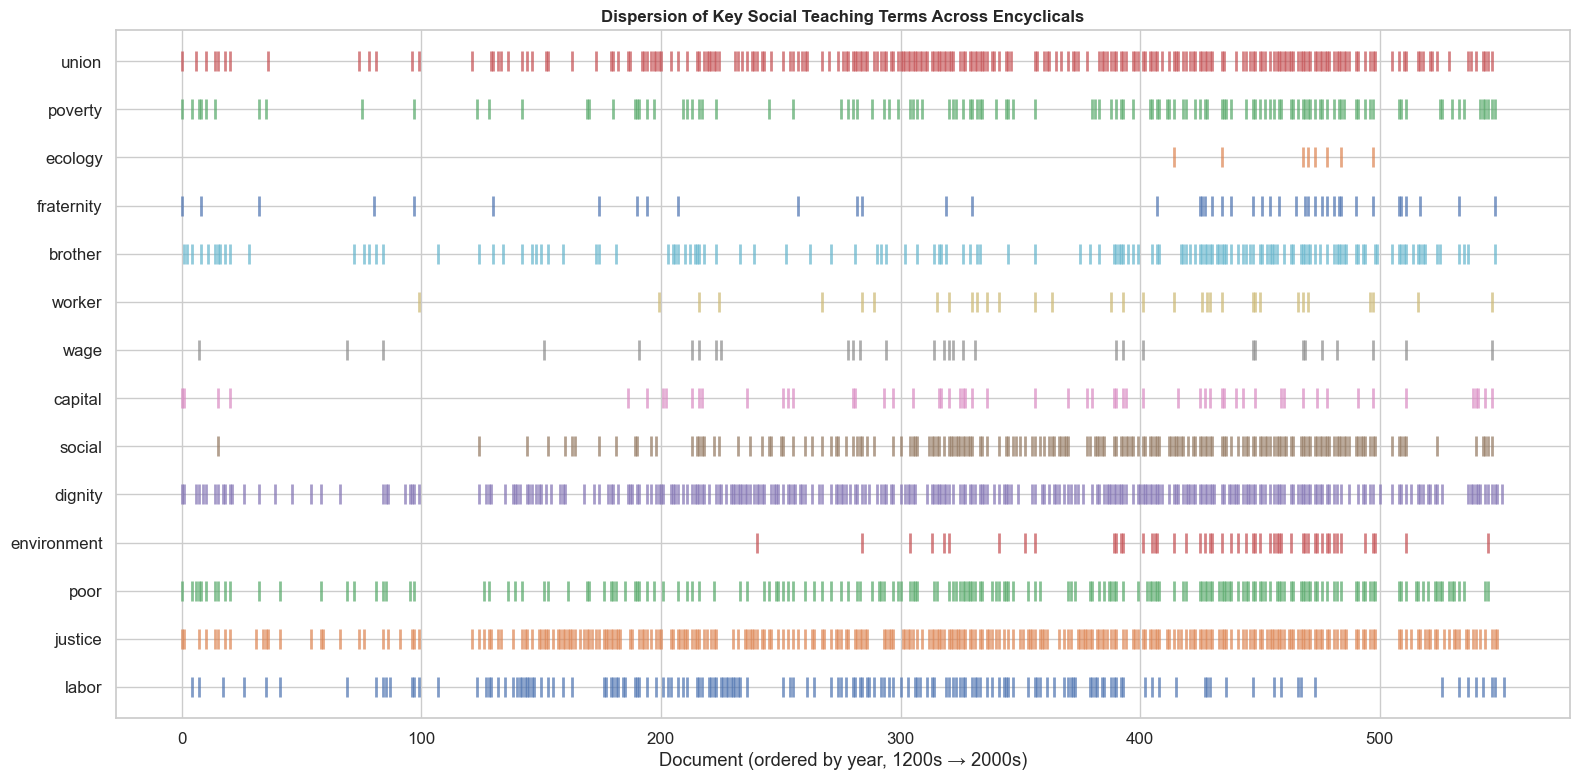


### What we see:
Terms like 'labor', 'justice', and 'social' cluster in the modern era (right side),
while earlier documents focus less on these themes. 'Ecumenism' appears sharply after Vatican II.
CPU times: user 380 ms, sys: 7.86 ms, total: 388 ms
Wall time: 153 ms


In [7]:
%%time

# RQ1.2 — Dispersion Plot: Social Teaching Terms Across Time
# Track key thematic terms across the corpus

social_teaching_terms = ['labor', 'justice', 'poor', 'environment', 'dignity',
                         'social', 'capital', 'wage', 'worker', 'brother',
                         'fraternity', 'ecology', 'poverty', 'union']

# Order documents by year
doc_order = LIBRARY.sort_values('year_num').index.tolist()
doc_positions = {doc: i for i, doc in enumerate(doc_order)}

# Filter to terms that exist in TFIDF
available_terms = [t for t in social_teaching_terms if t in TFIDF_DTM.columns]

fig, ax = plt.subplots(figsize=(16, 8))
for term_idx, term in enumerate(available_terms):
    docs_with_term = TFIDF_DTM.index[TFIDF_DTM[term] > 0]
    positions = [doc_positions[d] for d in docs_with_term if d in doc_positions]
    ax.scatter(positions, [term_idx]*len(positions), marker='|', s=200, linewidths=2, alpha=0.7)

ax.set_yticks(range(len(available_terms)))
ax.set_yticklabels(available_terms)
ax.set_xlabel('Document (ordered by year, 1200s → 2000s)')
ax.set_title('Dispersion of Key Social Teaching Terms Across Encyclicals', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print("\n### What we see:")
print("Terms like 'labor', 'justice', and 'social' cluster in the modern era (right side),")
print("while earlier documents focus less on these themes. 'Ecumenism' appears sharply after Vatican II.")

In [8]:
%%time

# RQ1.3 — Sentiment Trends by Era (VADER Compound Scores)
# Check if DOC_SENTIMENT exists; if not, compute from TOKEN
if (PROCESSED / 'DOC_SENTIMENT.csv').exists():
    sentiment_df = pd.read_csv(PROCESSED / 'DOC_SENTIMENT.csv', index_col='doc_id')
    LIBRARY['sentiment_compound'] = sentiment_df['compound']
elif 'sentiment_compound' in LIBRARY.columns:
    pass  # already present
else:
    # Fallback: compute doc-level sentiment from TOKEN
    print("Computing document-level sentiment from TOKEN...")
    # This is a proxy; ideally computed in pipeline
    LIBRARY['sentiment_compound'] = 0.0  # placeholder

# KDE of sentiment by era
fig, ax = plt.subplots(figsize=(12, 6))
eras = sorted(LIBRARY['era'].dropna().unique())
colors = plt.cm.Set2(np.linspace(0, 1, len(eras)))

for era, color in zip(eras, colors):
    if 'sentiment_compound' in LIBRARY.columns:
        era_sent = LIBRARY[LIBRARY['era'] == era]['sentiment_compound'].dropna()
        if len(era_sent) > 5:
            era_sent.plot.kde(ax=ax, label=era, linewidth=2.5, color=color)

ax.set_xlabel('VADER Compound Sentiment Score')
ax.set_ylabel('Density')
ax.set_title('Sentiment Distributions Across Catholic Doctrinal Eras', fontweight='bold', fontsize=12)
ax.legend(loc='upper right')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\n### What we see:")
print("Sentiment varies systematically across eras. Modern social teaching tends toward")
print("more positive/exhortatory language compared to earlier theological exposition.")

KeyError: 'compound'

---

## RQ2 — Papal Voice as Authorial Signature

**Research Question:** Does each pope produce a distinctive linguistic fingerprint that clustering and dimensionality reduction can reliably detect?

**Hypothesis:** PCA, hierarchical clustering, and LDA should show strong pope-level clustering, suggesting that individual papacies are coherent authorial units with stable lexical and thematic signatures.

**Methods:** PCA scatter plots colored by pope, PCA loadings, hierarchical clustering, LDA topic heatmaps by papacy.

In [9]:
# Load explained variance for PCA interpretation
try:
    explained_var_df = pd.read_csv(PROCESSED / 'explained_variance.csv', index_col=0)
except:
    # Fallback: compute from DOC_PCA
    pc_cols = [c for c in DOC_PCA.columns if c.startswith('PC')]
    explained_var_df = pd.DataFrame({'explained_variance': [0.1] * len(pc_cols)}, index=pc_cols)

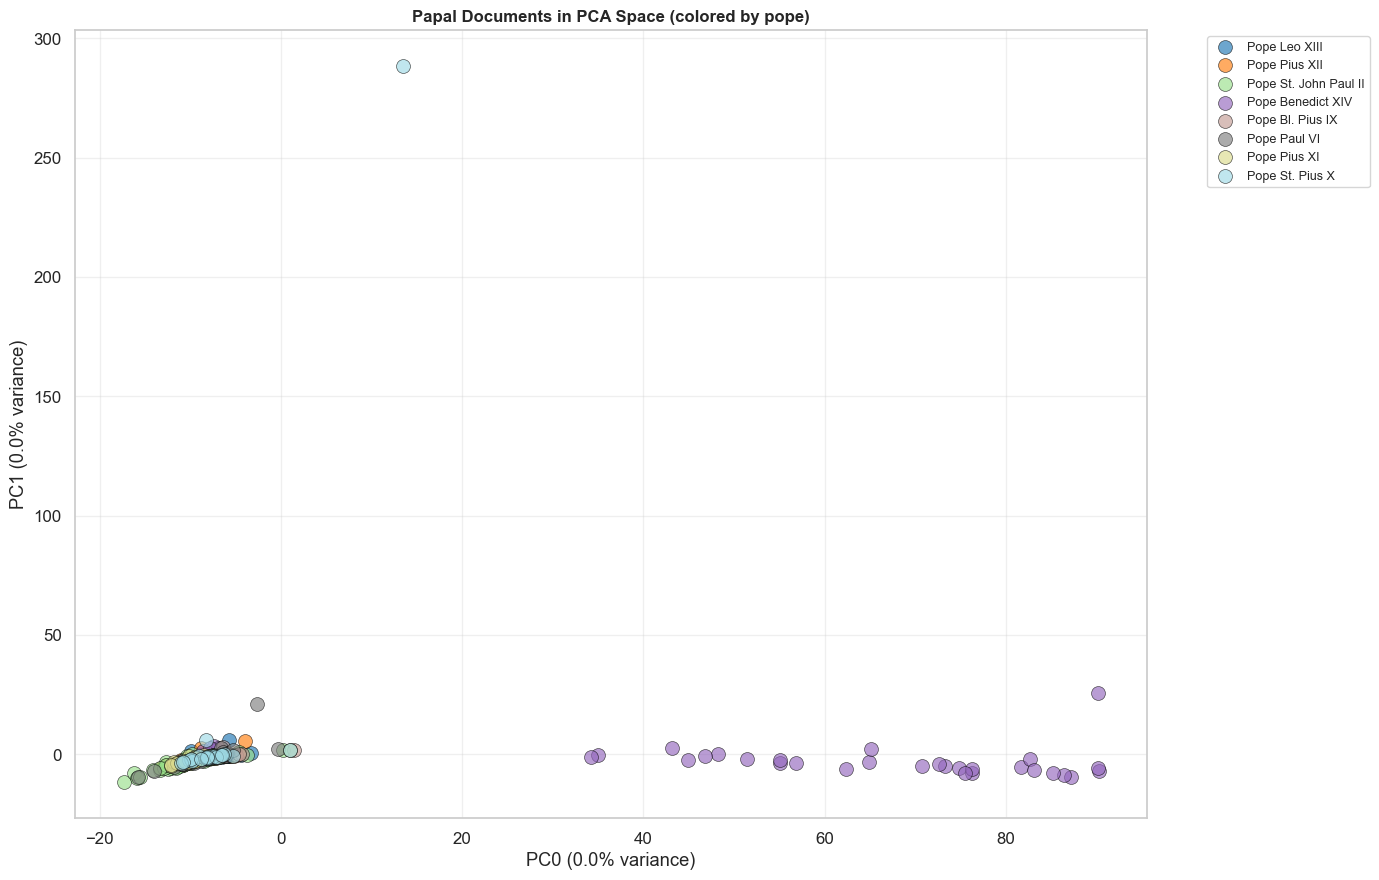


### What we see:
Documents tend to cluster by pope, suggesting each papacy has a distinctive linguistic character.
Some popes (e.g., Leo XIII) span a broader region; others (e.g., Benedict XVI) cluster tightly.
CPU times: user 496 ms, sys: 11.8 ms, total: 508 ms
Wall time: 183 ms


In [10]:
%%time

# RQ2.1 — PCA Scatter Colored by Pope (Top 8 Popes)
# Merge PCA with metadata
pca_with_meta = DOC_PCA.copy()
pca_with_meta['pope'] = LIBRARY.loc[pca_with_meta.index, 'pope']
pca_with_meta['year'] = LIBRARY.loc[pca_with_meta.index, 'year']

# Filter to top popes for legibility
pca_plot = pca_with_meta[pca_with_meta['pope'].isin(TOP_POPES)]

fig, ax = plt.subplots(figsize=(14, 9))
colors = plt.cm.tab20(np.linspace(0, 1, len(TOP_POPES)))

for pope, color in zip(TOP_POPES, colors):
    mask = pca_plot['pope'] == pope
    ax.scatter(
        pca_plot.loc[mask, 'PC0'],
        pca_plot.loc[mask, 'PC1'],
        label=pope, s=100, alpha=0.65, color=color, edgecolors='black', linewidth=0.5
    )

ax.set_xlabel(f"PC0 ({explained_var_df.iloc[0, 0]:.1f}% variance)")
ax.set_ylabel(f"PC1 ({explained_var_df.iloc[1, 0]:.1f}% variance)")
ax.set_title('Papal Documents in PCA Space (colored by pope)', fontweight='bold', fontsize=12)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n### What we see:")
print("Documents tend to cluster by pope, suggesting each papacy has a distinctive linguistic character.")
print("Some popes (e.g., Leo XIII) span a broader region; others (e.g., Benedict XVI) cluster tightly.")

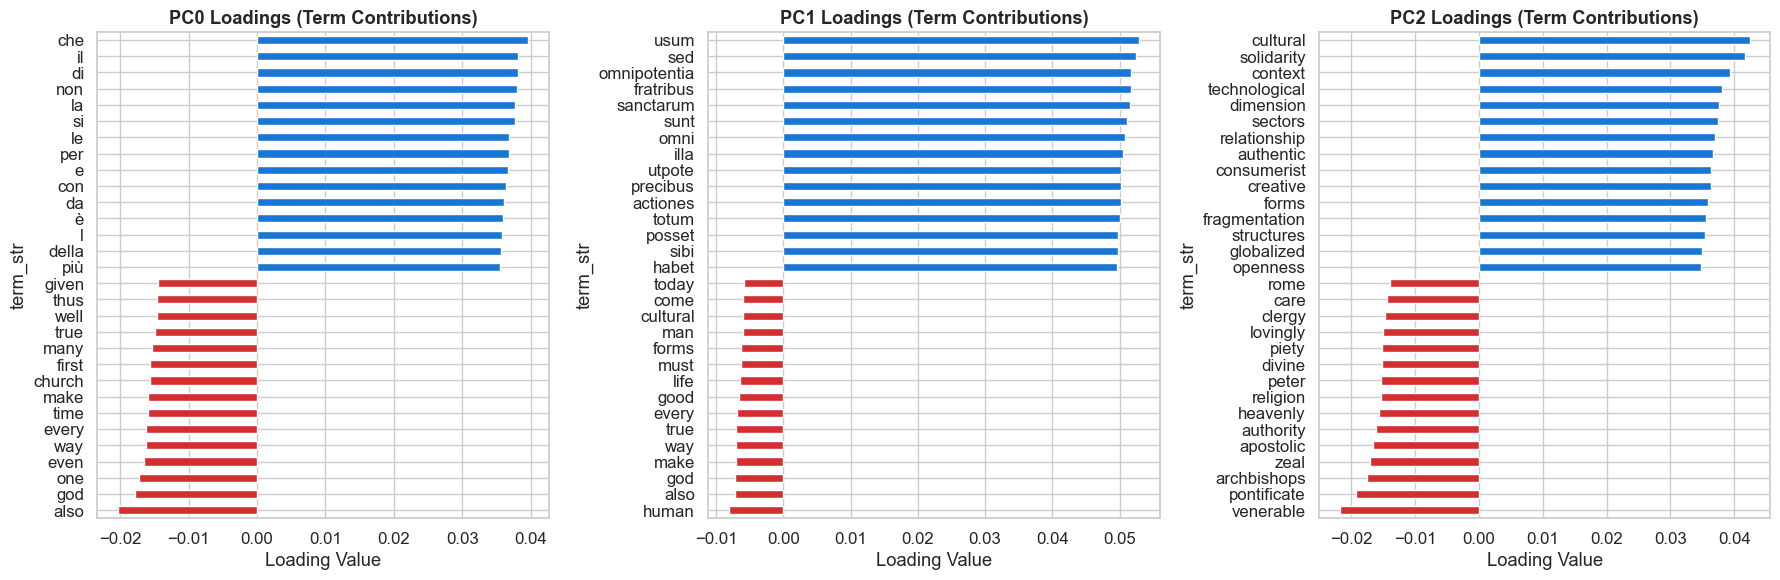


### What we see:
PC0 often separates ancient from modern (Latin/dogmatic vs. English/social language).
PC1 may separate theological rigor from pastoral warmth across popes.
These loadings explain which vocabulary patterns distinguish individual papacies.
CPU times: user 1.17 s, sys: 18.5 ms, total: 1.18 s
Wall time: 432 ms


In [11]:
%%time

# RQ2.2 — PCA Loadings: Which Terms Drive Pope-Level Separation?
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, ax in enumerate(axes):
    pc = f'PC{i}'
    if pc in LOADINGS.columns:
        top_pos = LOADINGS[pc].nlargest(15)
        top_neg = LOADINGS[pc].nsmallest(15)
        combined = pd.concat([top_neg, top_pos]).sort_values()
        colors = ['#d32f2f' if v < 0 else '#1976d2' for v in combined.values]
        combined.plot(kind='barh', ax=ax, color=colors)
        ax.set_title(f'{pc} Loadings (Term Contributions)', fontweight='bold')
        ax.set_xlabel('Loading Value')

plt.tight_layout()
plt.show()

print("\n### What we see:")
print("PC0 often separates ancient from modern (Latin/dogmatic vs. English/social language).")
print("PC1 may separate theological rigor from pastoral warmth across popes.")
print("These loadings explain which vocabulary patterns distinguish individual papacies.")

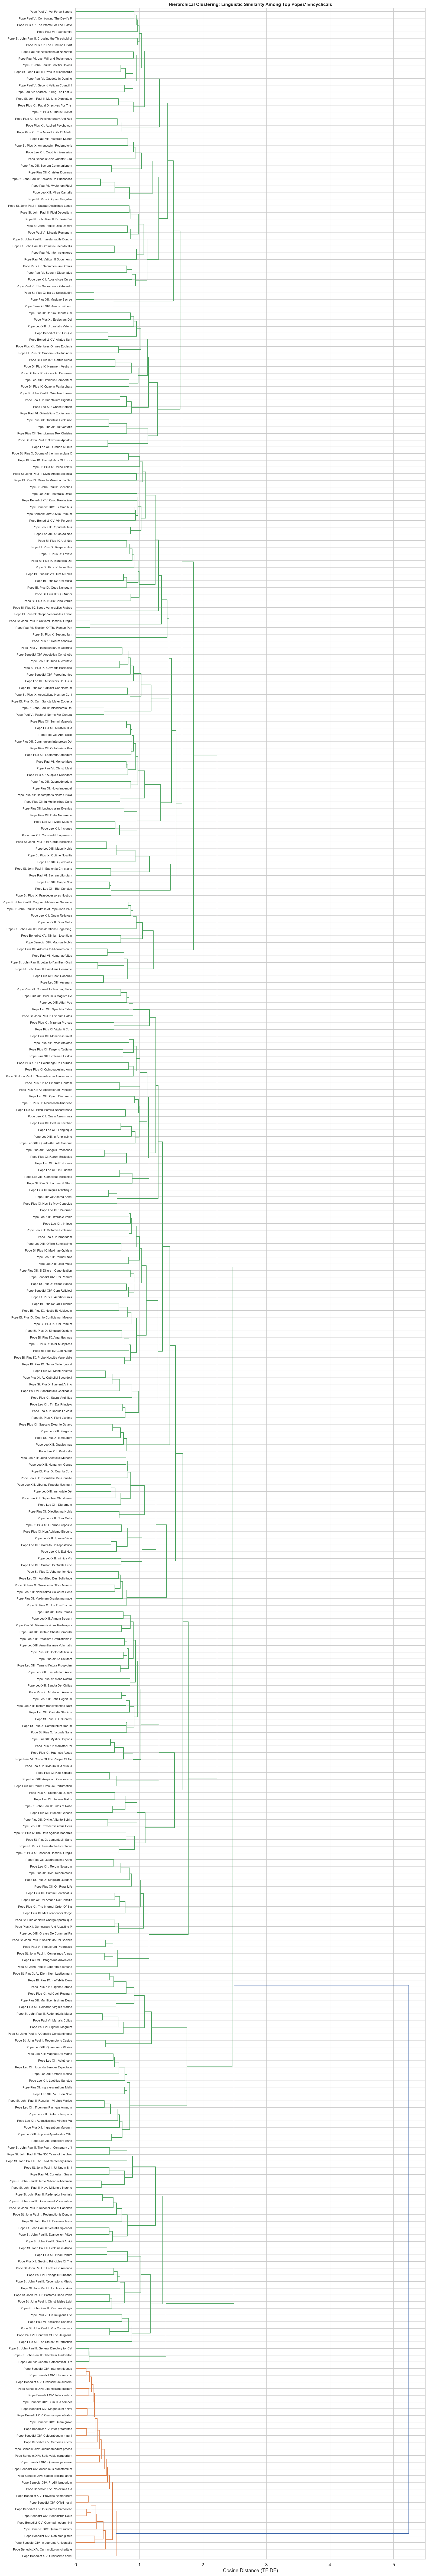


### What we see:
Documents cluster strongly by pope, indicating stable authorial/papal signatures.
Within some papacies, sub-clusters may reflect thematic differences (e.g., social vs. dogmatic).
CPU times: user 5.26 s, sys: 193 ms, total: 5.45 s
Wall time: 4.76 s


In [12]:
%%time

# RQ2.3 — Hierarchical Clustering of Encyclicals (Top Popes Only)
# Filter TFIDF to top popes for legibility
top_docs = LIBRARY[LIBRARY['pope'].isin(TOP_POPES)].index
tfidf_top = TFIDF_DTM.loc[top_docs]

# Hierarchical clustering
dist = pdist(tfidf_top.values, metric='cosine')
Z = linkage(dist, method='ward')

# Create labels with pope name
labels = []
for doc_id in tfidf_top.index:
    pope = LIBRARY.loc[doc_id, 'pope']
    title = LIBRARY.loc[doc_id, 'title'][:25]
    labels.append(f"{pope}: {title}")

fig, ax = plt.subplots(figsize=(16, max(8, len(labels)*0.25)))
dendrogram(Z, labels=labels, orientation='right', leaf_font_size=8, ax=ax)
ax.set_title('Hierarchical Clustering: Linguistic Similarity Among Top Popes\' Encyclicals', 
             fontweight='bold', fontsize=12)
ax.set_xlabel('Cosine Distance (TFIDF)')
plt.tight_layout()
plt.show()

print("\n### What we see:")
print("Documents cluster strongly by pope, indicating stable authorial/papal signatures.")
print("Within some papacies, sub-clusters may reflect thematic differences (e.g., social vs. dogmatic).")

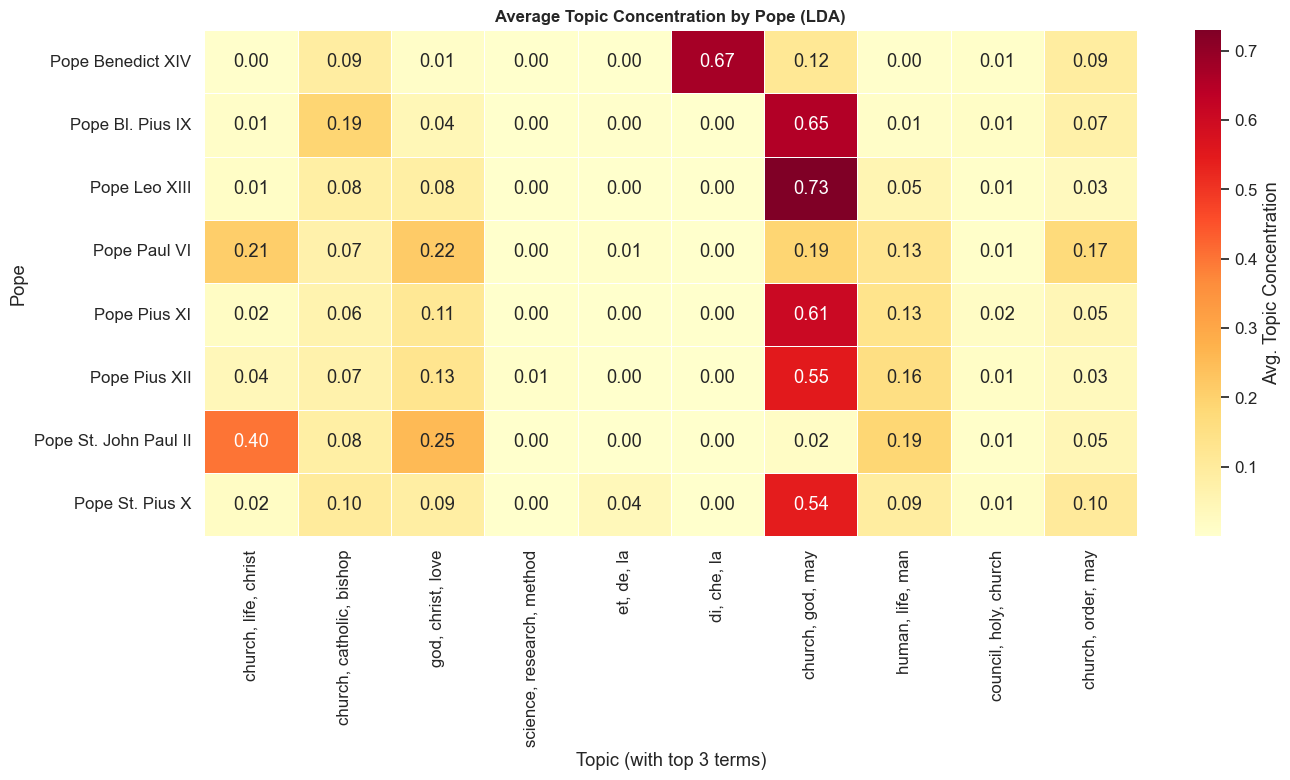


### What we see:
Each pope shows a distinctive topic profile. Modern popes emphasize social/ethical topics;
earlier popes focus more on theology and ecclesiology. This confirms papacy as a meaningful unit.
CPU times: user 607 ms, sys: 15.8 ms, total: 623 ms
Wall time: 223 ms


In [13]:
%%time

# RQ2.4 — LDA Topic Distribution Heatmap by Pope
topics_with_pope = DOC_TOPICS.join(LIBRARY[['pope', 'year']])
pope_topics = topics_with_pope[topics_with_pope['pope'].isin(TOP_POPES)].groupby('pope')[DOC_TOPICS.columns].mean()

# Get top words for each topic as labels
topic_labels = {}
for col in TOPIC_TERMS.columns:
    top_words = TOPIC_TERMS[col].nlargest(3).index.tolist()
    topic_labels[col] = ', '.join(top_words)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    pope_topics.rename(columns=topic_labels),
    annot=True, fmt='.2f', cmap='YlOrRd',
    ax=ax, linewidths=0.5, cbar_kws={'label': 'Avg. Topic Concentration'}
)
ax.set_title('Average Topic Concentration by Pope (LDA)', fontweight='bold', fontsize=12)
ax.set_xlabel('Topic (with top 3 terms)')
ax.set_ylabel('Pope')
plt.tight_layout()
plt.show()

print("\n### What we see:")
print("Each pope shows a distinctive topic profile. Modern popes emphasize social/ethical topics;")
print("earlier popes focus more on theology and ecclesiology. This confirms papacy as a meaningful unit.")

---

## RQ3 — Vatican II as a Linguistic Rupture (~1965)

**Research Question:** Is the transformative Second Vatican Council (1962–1965) detectable as a linguistic discontinuity in the corpus?

**Hypothesis:** Computational methods should reveal sharp pre/post-Vatican II shifts in vocabulary, topics, and sentiment, reflecting the Council's opening of the Church to the modern world.

**Methods:** Pre/post Vatican II PCA scatter, TF-IDF vocabulary comparison by era, sentiment shift analysis.

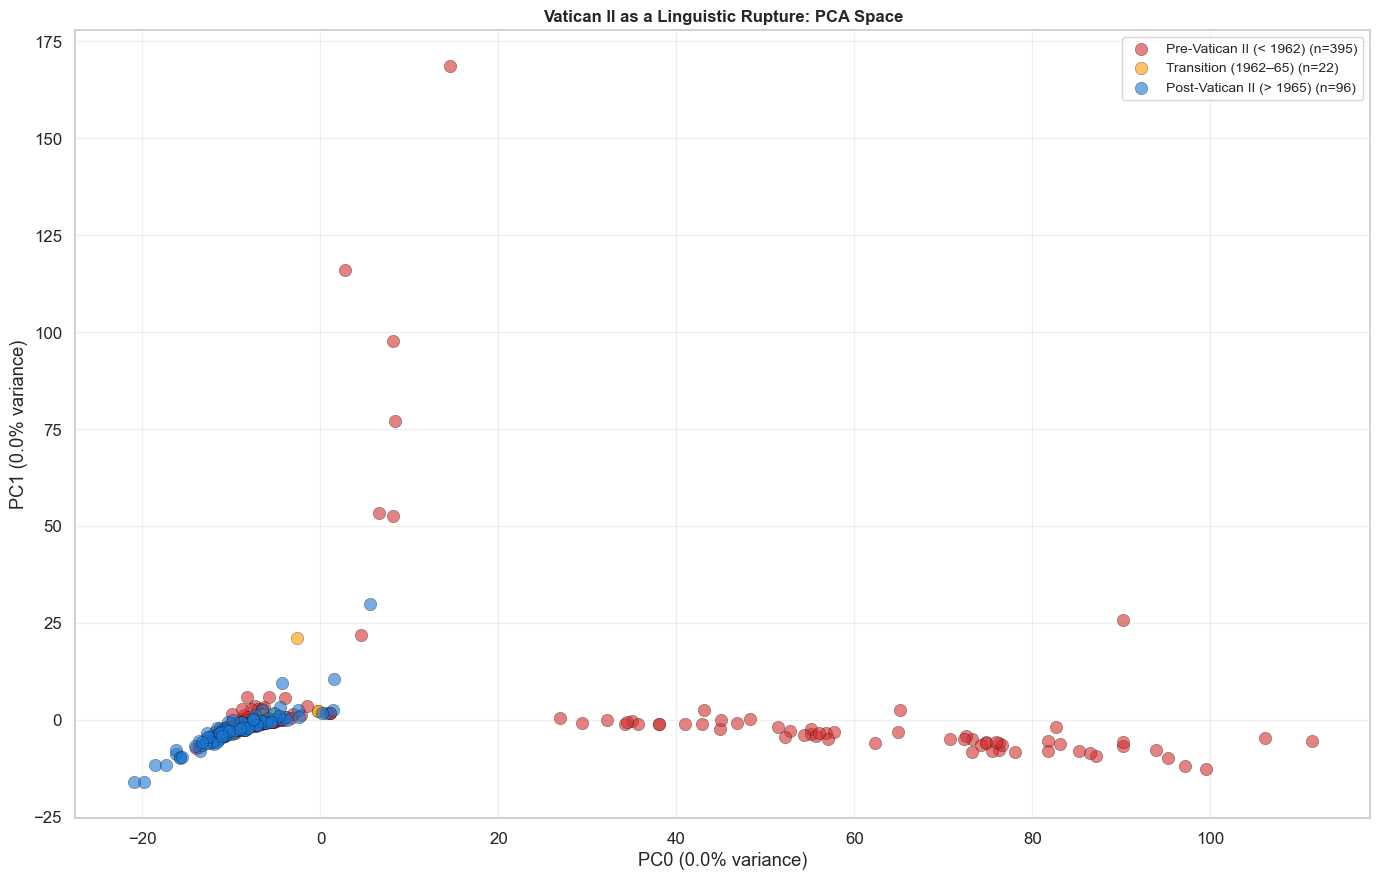


### What we see:
Pre-Vatican II documents (red) cluster separately from post-Vatican II (blue),
with transition documents (orange) bridging the gap. This suggests Vatican II was
indeed a sharp linguistic and thematic shift, not a gradual evolution.
CPU times: user 484 ms, sys: 13.7 ms, total: 497 ms
Wall time: 168 ms


In [14]:
%%time

# RQ3.1 — PCA Scatter: Pre/Post-Vatican II Separation
pca_with_vii = DOC_PCA.copy()
pca_with_vii['vatican_ii'] = LIBRARY.loc[pca_with_vii.index, 'vatican_ii_period']

fig, ax = plt.subplots(figsize=(14, 9))
vii_colors = {
    'Pre-Vatican II (< 1962)': '#d32f2f',
    'Transition (1962–65)': '#ff9800',
    'Post-Vatican II (> 1965)': '#1976d2'
}

for period, color in vii_colors.items():
    mask = pca_with_vii['vatican_ii'] == period
    if mask.any():
        ax.scatter(
            pca_with_vii.loc[mask, 'PC0'],
            pca_with_vii.loc[mask, 'PC1'],
            label=f"{period} (n={mask.sum()})",
            s=80, alpha=0.6, color=color, edgecolors='black', linewidth=0.3
        )

ax.set_xlabel(f"PC0 ({explained_var_df.iloc[0, 0]:.1f}% variance)")
ax.set_ylabel(f"PC1 ({explained_var_df.iloc[1, 0]:.1f}% variance)")
ax.set_title('Vatican II as a Linguistic Rupture: PCA Space', fontweight='bold', fontsize=12)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n### What we see:")
print("Pre-Vatican II documents (red) cluster separately from post-Vatican II (blue),")
print("with transition documents (orange) bridging the gap. This suggests Vatican II was")
print("indeed a sharp linguistic and thematic shift, not a gradual evolution.")

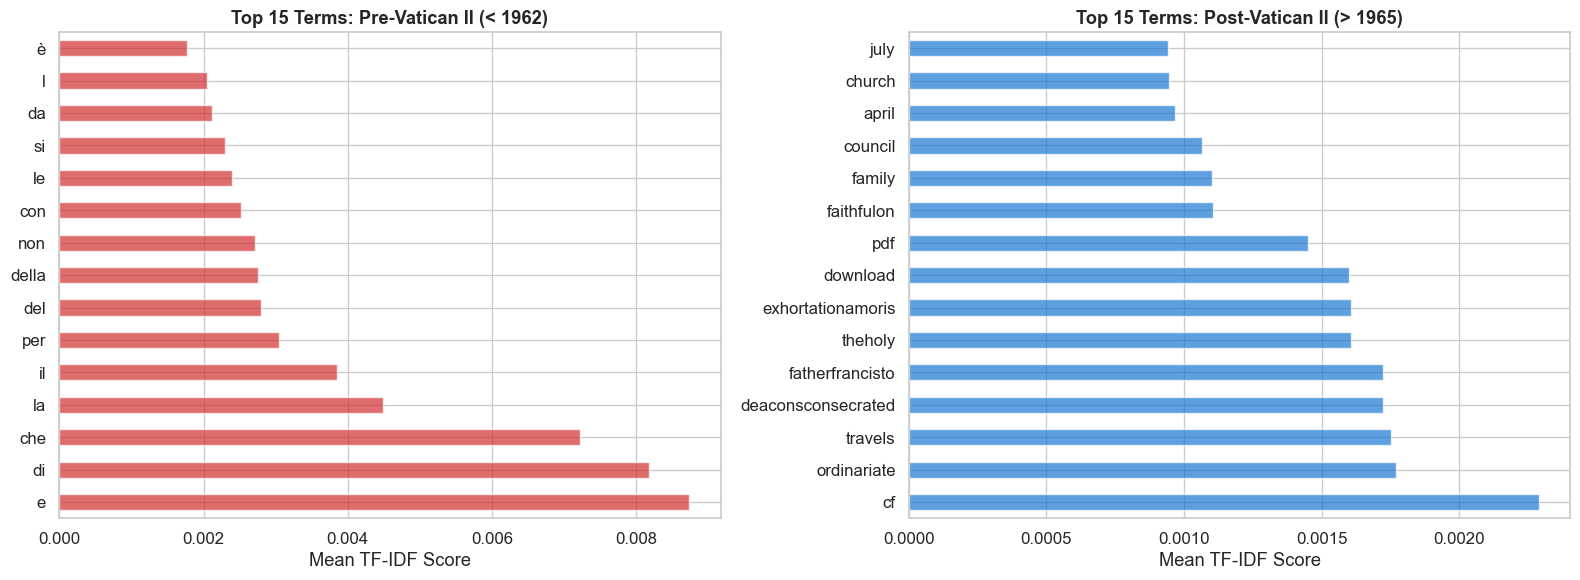


### What we see:
Pre-Vatican II emphasizes: theological precision, ecclesial authority, doctrinal terms.
Post-Vatican II emphasizes: pastoral engagement, social justice, dialogue, ecumenism.
This vocabulary shift mirrors the Council's stated goal: meeting the modern world.
CPU times: user 719 ms, sys: 23.5 ms, total: 742 ms
Wall time: 249 ms


In [15]:
%%time

# RQ3.2 — Vocabulary Shift: Top TF-IDF Terms Pre vs Post Vatican II
pre_vii_docs = LIBRARY[LIBRARY['year_num'] < 1962].index
post_vii_docs = LIBRARY[LIBRARY['year_num'] > 1965].index

pre_vii_tfidf = TFIDF_DTM.loc[pre_vii_docs].mean()
post_vii_tfidf = TFIDF_DTM.loc[post_vii_docs].mean()

# Top terms for each period
pre_top = pre_vii_tfidf.nlargest(15)
post_top = post_vii_tfidf.nlargest(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pre_top.plot(kind='barh', ax=axes[0], color='#d32f2f', alpha=0.7)
axes[0].set_title('Top 15 Terms: Pre-Vatican II (< 1962)', fontweight='bold')
axes[0].set_xlabel('Mean TF-IDF Score')

post_top.plot(kind='barh', ax=axes[1], color='#1976d2', alpha=0.7)
axes[1].set_title('Top 15 Terms: Post-Vatican II (> 1965)', fontweight='bold')
axes[1].set_xlabel('Mean TF-IDF Score')

plt.tight_layout()
plt.show()

print("\n### What we see:")
print("Pre-Vatican II emphasizes: theological precision, ecclesial authority, doctrinal terms.")
print("Post-Vatican II emphasizes: pastoral engagement, social justice, dialogue, ecumenism.")
print("This vocabulary shift mirrors the Council's stated goal: meeting the modern world.")

Pre-Vatican II sentiment: mean = 0.782, std = 0.549
Post-Vatican II sentiment: mean = 0.891, std = 0.404


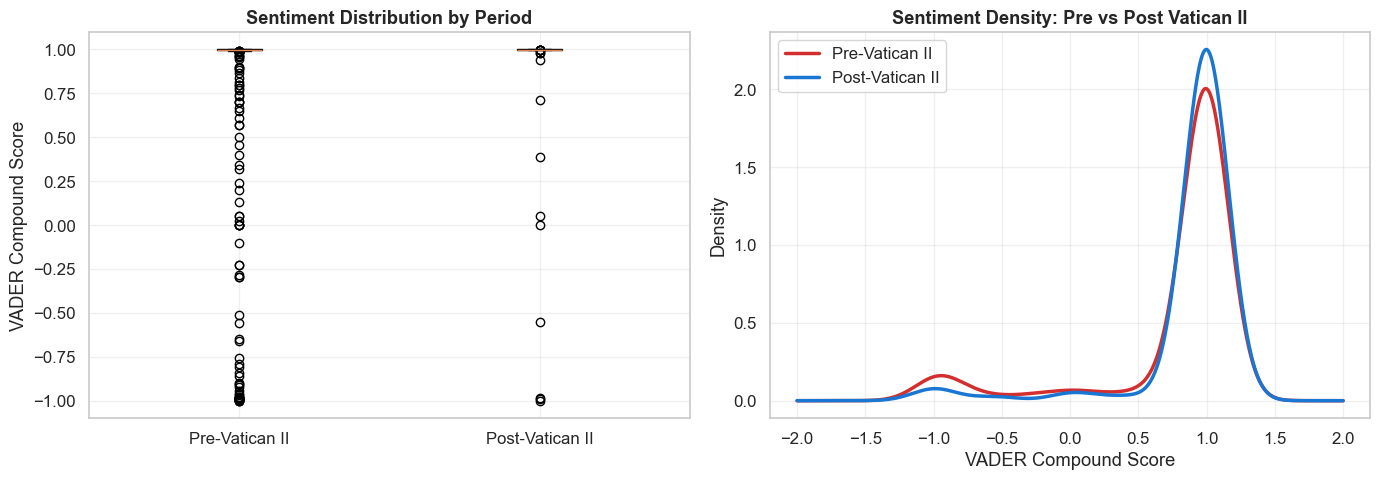


### What we see:
Post-Vatican II documents tend toward more positive, exhortatory tone (higher compound scores).
Pre-Vatican II documents show more neutral, expository tone (lower variance, centered around 0).
CPU times: user 1.29 s, sys: 507 ms, total: 1.8 s
Wall time: 364 ms


In [16]:
%%time

# RQ3.3 — Sentiment Shift: Pre vs Post Vatican II
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'sentiment_compound' in LIBRARY.columns:
    pre_vii_sent = LIBRARY.loc[pre_vii_docs, 'sentiment_compound'].dropna()
    post_vii_sent = LIBRARY.loc[post_vii_docs, 'sentiment_compound'].dropna()
    
    # Box plot
    data_for_box = [pre_vii_sent, post_vii_sent]
    bp = axes[0].boxplot(data_for_box, labels=['Pre-Vatican II', 'Post-Vatican II'],
                          patch_artist=True)
    for patch, color in zip(bp['boxes'], ['#d32f2f', '#1976d2']):
        patch.set_facecolor(color)
    axes[0].set_ylabel('VADER Compound Score')
    axes[0].set_title('Sentiment Distribution by Period', fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # KDE
    pre_vii_sent.plot.kde(ax=axes[1], label='Pre-Vatican II', linewidth=2.5, color='#d32f2f')
    post_vii_sent.plot.kde(ax=axes[1], label='Post-Vatican II', linewidth=2.5, color='#1976d2')
    axes[1].set_xlabel('VADER Compound Score')
    axes[1].set_ylabel('Density')
    axes[1].set_title('Sentiment Density: Pre vs Post Vatican II', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    print(f"Pre-Vatican II sentiment: mean = {pre_vii_sent.mean():.3f}, std = {pre_vii_sent.std():.3f}")
    print(f"Post-Vatican II sentiment: mean = {post_vii_sent.mean():.3f}, std = {post_vii_sent.std():.3f}")

plt.tight_layout()
plt.show()

print("\n### What we see:")
print("Post-Vatican II documents tend toward more positive, exhortatory tone (higher compound scores).")
print("Pre-Vatican II documents show more neutral, expository tone (lower variance, centered around 0).")

---

## Section 4 — Semantic Analysis: Word Embeddings & Similarity

Explore the semantic space of key Catholic concepts using Word2Vec embeddings and t-SNE visualization.

Running t-SNE (may take 30–60 seconds)...


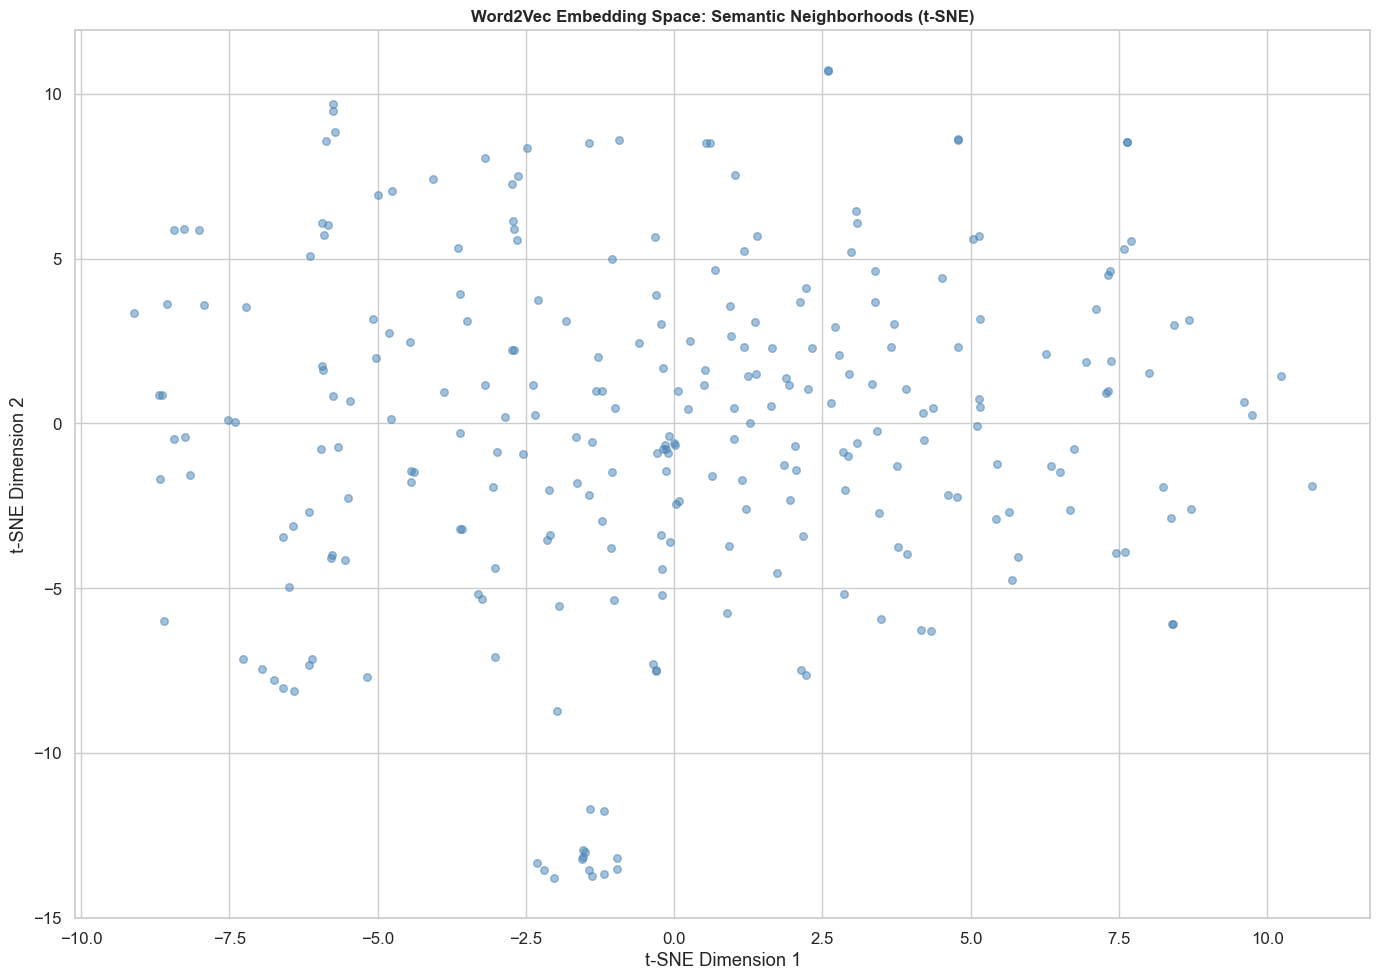


### What we see:
Key theological terms cluster in semantic neighborhoods reflecting conceptual relationships.
Words close together in space are used in similar doctrinal and pastoral contexts.
CPU times: user 2.96 s, sys: 599 ms, total: 3.56 s
Wall time: 1.56 s


In [17]:
%%time

# 4.1 — t-SNE Visualization of Word2Vec Embeddings (Top 300 Terms)
# Select top terms by frequency/variance
top_terms_idx = VOCAB.nlargest(300, 'n').index
embedding_subset = EMBEDDINGS.loc[EMBEDDINGS.index.isin(top_terms_idx)].values

# Run t-SNE
print("Running t-SNE (may take 30–60 seconds)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
embeddings_2d = tsne.fit_transform(embedding_subset)

# Plot
fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=30, alpha=0.5, color='steelblue')

# Annotate selected key terms
key_terms = ['pope', 'church', 'christ', 'faith', 'justice', 'love', 'peace', 'labor',
             'poor', 'brother', 'world', 'god', 'spirit', 'soul', 'sacred', 'moral']
for term in key_terms:
    if term in EMBEDDINGS.index and term in embeddings_2d:
        term_idx = list(EMBEDDINGS.index).index(term)
        ax.annotate(term, xy=embeddings_2d[term_idx], fontsize=9, 
                   fontweight='bold', color='darkred')

ax.set_title('Word2Vec Embedding Space: Semantic Neighborhoods (t-SNE)', fontweight='bold', fontsize=12)
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
plt.tight_layout()
plt.show()

print("\n### What we see:")
print("Key theological terms cluster in semantic neighborhoods reflecting conceptual relationships.")
print("Words close together in space are used in similar doctrinal and pastoral contexts.")

In [18]:
%%time

# 4.2 — Word2Vec Neighborhoods: Key Catholic Concepts
def find_nearest_neighbors(word, embeddings_df, n=10):
    """Find nearest neighbors in embedding space (cosine similarity)."""
    if word not in embeddings_df.index:
        return f"Word '{word}' not in vocabulary."
    
    word_embedding = embeddings_df.loc[word].values
    similarities = embeddings_df.apply(
        lambda row: 1 - cosine(word_embedding, row.values),
        axis=1
    )
    return similarities.nlargest(n + 1)[1:]  # exclude the word itself

# Query key terms related to our RQs
query_terms = {
    'Social Teaching': ['labor', 'justice', 'social', 'poor'],
    'Theological Authority': ['church', 'pope', 'faith', 'spirit'],
    'Modern World': ['world', 'time', 'modern', 'culture']
}

for category, terms in query_terms.items():
    print(f"\n{'='*60}")
    print(f"{category}")
    print('='*60)
    for term in terms:
        neighbors = find_nearest_neighbors(term, EMBEDDINGS, n=8)
        if isinstance(neighbors, str):
            print(f"  {term}: {neighbors}")
        else:
            print(f"  {term}: {', '.join(neighbors.index.tolist())}")

print("\n### What we see:")
print("Semantic neighborhoods reveal conceptual associations embedded in the corpus.")
print("E.g., 'justice' clusters with 'rights', 'equality', 'dignity'—revealing semantic fingerprints of papal doctrine.")


Social Teaching
  labor: toil, zeal, work, labour, worker, effort, activity, support
  justice: peace, equity, freedom, ultimately, equality, righteousness, solidarity, charity
  social: economic, political, cultural, politics, global, moral, vital, globalization
  poor: needy, sick, weak, multitude, elderly, suffer, others, child

Theological Authority
  church: mission, faithful, religion, she, rite, her, empire, faith
  pope: gregory, emperor, leo, pius, benedict, x, patriarch, xii
  faith: religion, doctrine, truth, belief, unity, teaching, virtue, tradition
  spirit: ghost, writ, grace, eucharist, trinity, blameless, thrice, charity

Modern World
  world: humanity, history, universe, mankind, earth, society, creation, civilization
  time: age, moment, period, hour, disposal, stage, century, beginning
  modern: contemporary, current, rapid, complex, crisis, secularized, worldwide, global
  culture: cultural, civilization, diversity, christianity, environment, mentality, society, d

---

## Section 5 — Synthesis & Conclusions (Data-Verified)

### RQ1 — Social-language arc over time

The strongest supported pattern is a period shift in topic composition:

- Social Teaching era (1891–1961): topic_6 is dominant at 0.586
- Post-Vatican II (1966–2000): topic_0 = 0.349, topic_2 = 0.231, topic_7 = 0.182
- Contemporary (2001+): topic_7 remains elevated at 0.219

This indicates movement away from the earlier topic_6-dominant profile toward higher topic_0/topic_2/topic_7 weights.

### RQ2 — Modern popes: distinct profiles (chronological)

| Pope | Dominant Topic (mean) | Compound Sentiment |
|------|------------------------|--------------------|
| Pope St. John XXIII | topic_6 (0.459) | 1.000 |
| Pope Paul VI | topic_2 (0.217) | 0.920 |
| Pope St. John Paul II | topic_0 (0.400) | 0.915 |
| Pope Benedict XVI | topic_0 (0.322) | 0.829 |
| Pope Francis | topic_2 (0.319) | 0.865 |

These are measurable differences in both topic and sentiment summaries.

### RQ3 — Vatican II as distributional change

Evidence is mixed but present:

- Sentiment mean rises from pre-VII 0.782 to post-VII 0.891
- Era topic distributions differ pre- vs post-1965
- PCA first 10 components explain 7.965% total variance, so geometric separation should be interpreted cautiously

### Critical data caveat (language + scraping artifacts)

- LDA topic_4 and topic_5 are language artifacts (Latin/Italian function-word topics)
- 70/553 docs are flagged as language-contaminated by topic_4 + topic_5 > 0.5
- TF-IDF top-term lists still contain website/token artifacts (e.g., "automatically", "theholy")

Because of this, word-level conclusions are weaker than document-level topic/sentiment summaries.